# RoBERTa Multi-Task Training

- One shared RoBERTa encoder
- One head for polarity: `Negative`, `Neutral`, `Positive`
- One head for subjectivity: `Objective`, `Subjective`

In [39]:
!pip -q install -U "transformers[torch]" datasets accelerate scikit-learn "pandas>=2.2.2,<3" matplotlib seaborn openpyxl torchview torchviz graphviz


In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchview import draw_graph
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
import os
import warnings
from transformers import logging as transformers_logging

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## Configurations

In [ ]:
TEXT_COL = 'text_transformer'
POLARITY_COL = 'label_sentiment'
SUBJECTIVITY_COL = 'label_subjectivity'

POLARITY_LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
POLARITY_ID2LABEL = {idx: label for label, idx in POLARITY_LABEL2ID.items()}
SUBJECTIVITY_LABEL2ID = {'Objective': 0, 'Subjective': 1}
SUBJECTIVITY_ID2LABEL = {idx: label for label, idx in SUBJECTIVITY_LABEL2ID.items()}

BASE_DIR = Path('/content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project')
TRAIN_HN_CSV = BASE_DIR / 'data/preprocessed-data/corpus_training_hn.csv'
TRAIN_KAGGLE_CSV = BASE_DIR / 'data/preprocessed-data/corpus_training_kaggle.csv'
EVAL_CSV = BASE_DIR / 'data/preprocessed-data/corpus_evaluation.csv'
OUTPUT_DIR = BASE_DIR / 'outputs/roberta_multitask_combined'

TRAIN_MODE = 'combined'
MODEL_NAME = 'roberta-base'  # loads pretrained Facebook AI RoBERTa
MAX_LENGTH = 384
SEED = 42
LEARNING_RATE = 5e-6
NUM_EPOCHS = 5
WEIGHT_DECAY = 0.08
DROPOUT_PROB = 0.2
LABEL_SMOOTHING = 0.05
VAL_TEST_SIZE = 0.15
EARLY_STOPPING_PATIENCE = 2
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
USE_WEIGHTED_LOSS = True
POLARITY_LOSS_WEIGHT = 1.0
SUBJECTIVITY_LOSS_WEIGHT = 1.0
USE_OVERSAMPLING = False

## Data Preparation

In [ ]:
polarity_cap_map = {'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'}
subjectivity_cap_map = {'objective': 'Objective', 'subjective': 'Subjective'}


def load_multitask_csv(path, text_col, polarity_col, subjectivity_col, source_name):
    df = pd.read_csv(path, encoding='utf-8')
    df = df[[text_col, polarity_col, subjectivity_col]].dropna().copy()
    df[text_col] = df[text_col].astype(str).str.strip()
    df[polarity_col] = df[polarity_col].astype(str).str.strip().replace(polarity_cap_map)
    df[subjectivity_col] = df[subjectivity_col].astype(str).str.strip().replace(subjectivity_cap_map)
    df = df.rename(
        columns={
            text_col: TEXT_COL,
            polarity_col: POLARITY_COL,
            subjectivity_col: SUBJECTIVITY_COL,
        }
    )
    df['source'] = source_name
    return df


if TRAIN_MODE == 'combined':
    parts = [
        load_multitask_csv(TRAIN_HN_CSV, TEXT_COL, POLARITY_COL, SUBJECTIVITY_COL, 'hn'),
        load_multitask_csv(TRAIN_KAGGLE_CSV, TEXT_COL, POLARITY_COL, SUBJECTIVITY_COL, 'kaggle'),
    ]
elif TRAIN_MODE == 'hn_only':
    parts = [
        load_multitask_csv(TRAIN_HN_CSV, TEXT_COL, POLARITY_COL, SUBJECTIVITY_COL, 'hn'),
    ]
else:
    parts = [
        load_multitask_csv(TRAIN_KAGGLE_CSV, TEXT_COL, POLARITY_COL, SUBJECTIVITY_COL, 'kaggle'),
    ]

df = pd.concat(parts, ignore_index=True)
df['polarity_labels'] = df[POLARITY_COL].map(POLARITY_LABEL2ID)
df['subjectivity_labels'] = df[SUBJECTIVITY_COL].map(SUBJECTIVITY_LABEL2ID)
df = df.dropna(subset=['polarity_labels', 'subjectivity_labels']).copy()
df['polarity_labels'] = df['polarity_labels'].astype(int)
df['subjectivity_labels'] = df['subjectivity_labels'].astype(int)

source_counts = df['source'].value_counts()
polarity_counts = df[POLARITY_COL].value_counts().reindex(POLARITY_LABEL2ID.keys(), fill_value=0)
subjectivity_counts = df[SUBJECTIVITY_COL].value_counts().reindex(SUBJECTIVITY_LABEL2ID.keys(), fill_value=0)

print(f'Train mode: {TRAIN_MODE}')
print(f'Total rows with both labels: {len(df)}')
print('Source counts:')
print(source_counts)
print('\nPolarity counts:')
print(polarity_counts)
print('\nSubjectivity counts:')
print(subjectivity_counts)

stratify_key = df[POLARITY_COL] + ' | ' + df[SUBJECTIVITY_COL]


def oversample_multitask_joint(frame, seed=SEED):
    joint = frame[POLARITY_COL] + ' | ' + frame[SUBJECTIVITY_COL]
    counts = joint.value_counts()
    target = int(counts.max())
    parts = []
    for key in counts.index:
        group = frame[joint == key]
        n = len(group)
        parts.append(group.sample(n=target, replace=(n < target), random_state=seed))
    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


train_df, val_df = train_test_split(
    df,
    test_size=VAL_TEST_SIZE,
    random_state=SEED,
    stratify=stratify_key,
)

print(f'\nTrain rows: {len(train_df)}')
print(f'Validation rows: {len(val_df)}')

if USE_OVERSAMPLING:
    _n0 = len(train_df)
    train_df = oversample_multitask_joint(train_df)
    print(f'USE_OVERSAMPLING: training set {_n0} -> {len(train_df)} rows')
    print(train_df[POLARITY_COL].value_counts())
    print(train_df[SUBJECTIVITY_COL].value_counts())


Train mode: combined
Total rows with both labels: 50899
Source counts:
source
kaggle    50000
hn          899
Name: count, dtype: int64

Polarity counts:
label_sentiment
Negative    10157
Neutral     12953
Positive    27789
Name: count, dtype: int64

Subjectivity counts:
label_subjectivity
Objective     12953
Subjective    37946
Name: count, dtype: int64

Train rows: 43264
Validation rows: 7635


## Tokenisation

In [ ]:
def tokenize_datasets(train_df, val_df, model_name=MODEL_NAME, max_length=MAX_LENGTH):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def to_dataset(frame):
        ds = Dataset.from_pandas(
            frame[[TEXT_COL, 'polarity_labels', 'subjectivity_labels']].reset_index(drop=True)
        )
        return ds.map(
            lambda x: tokenizer(x[TEXT_COL], truncation=True, max_length=max_length),
            batched=True,
            remove_columns=[TEXT_COL],
        )

    train_tok = to_dataset(train_df)
    val_tok = to_dataset(val_df)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    return tokenizer, train_tok, val_tok, data_collator


def compute_class_weights(train_df, label_column, label2id):
    counts = train_df[label_column].value_counts().sort_index()
    num_classes = len(label2id)
    inv = (counts.sum() / (num_classes * counts)).astype(float)
    weights = np.sqrt(inv).values
    return torch.tensor(weights, dtype=torch.float)

tokenizer, train_tok, val_tok, data_collator = tokenize_datasets(train_df, val_df)
polarity_class_weights = compute_class_weights(train_df, 'polarity_labels', POLARITY_LABEL2ID)
subjectivity_class_weights = compute_class_weights(train_df, 'subjectivity_labels', SUBJECTIVITY_LABEL2ID)

print('Polarity class weights:', polarity_class_weights.tolist())
print('Subjectivity class weights:', subjectivity_class_weights.tolist())

Map:   0%|          | 0/43264 [00:00<?, ? examples/s]

Map:   0%|          | 0/7635 [00:00<?, ? examples/s]

Polarity class weights: [1.2924740314483643, 1.1444822549819946, 0.7813643217086792]
Subjectivity class weights: [1.4016987085342407, 0.8189483880996704]


## Multi-Task RoBERTa Model

In [45]:
class RobertaForMultiTaskClassification(nn.Module):
    def __init__(self, model_name, polarity_num_labels, subjectivity_num_labels, dropout_prob=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout_prob)
        self.polarity_classifier = nn.Linear(hidden_size, polarity_num_labels)
        self.subjectivity_classifier = nn.Linear(hidden_size, subjectivity_num_labels)
        self.config = self.encoder.config

    def forward(self, input_ids=None, attention_mask=None, polarity_labels=None, subjectivity_labels=None, **kwargs):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask, **kwargs)
        pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)

        polarity_logits = self.polarity_classifier(pooled)
        subjectivity_logits = self.subjectivity_classifier(pooled)

        loss = None
        if polarity_labels is not None and subjectivity_labels is not None:
            ls = LABEL_SMOOTHING if LABEL_SMOOTHING > 0 else 0.0
            polarity_loss = F.cross_entropy(polarity_logits, polarity_labels, label_smoothing=ls)
            subjectivity_loss = F.cross_entropy(subjectivity_logits, subjectivity_labels, label_smoothing=ls)
            loss = POLARITY_LOSS_WEIGHT * polarity_loss + SUBJECTIVITY_LOSS_WEIGHT * subjectivity_loss

        return {
            'loss': loss,
            'polarity_logits': polarity_logits,
            'subjectivity_logits': subjectivity_logits,
        }


class MultiTaskTrainer(Trainer):
    def __init__(self, *args, polarity_class_weights=None, subjectivity_class_weights=None, use_weighted_loss=False, **kwargs):
        super().__init__(*args, **kwargs)
        self.polarity_class_weights = polarity_class_weights
        self.subjectivity_class_weights = subjectivity_class_weights
        self.use_weighted_loss = use_weighted_loss

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        polarity_labels = inputs.pop('polarity_labels')
        subjectivity_labels = inputs.pop('subjectivity_labels')

        outputs = model(**inputs)
        polarity_logits = outputs['polarity_logits']
        subjectivity_logits = outputs['subjectivity_logits']

        ls = LABEL_SMOOTHING if LABEL_SMOOTHING > 0 else 0.0
        if self.use_weighted_loss:
            polarity_loss = F.cross_entropy(
                polarity_logits,
                polarity_labels,
                weight=self.polarity_class_weights.to(polarity_logits.device),
                label_smoothing=ls,
            )
            subjectivity_loss = F.cross_entropy(
                subjectivity_logits,
                subjectivity_labels,
                weight=self.subjectivity_class_weights.to(subjectivity_logits.device),
                label_smoothing=ls,
            )
        else:
            polarity_loss = F.cross_entropy(polarity_logits, polarity_labels, label_smoothing=ls)
            subjectivity_loss = F.cross_entropy(subjectivity_logits, subjectivity_labels, label_smoothing=ls)

        loss = POLARITY_LOSS_WEIGHT * polarity_loss + SUBJECTIVITY_LOSS_WEIGHT * subjectivity_loss
        outputs['loss'] = loss
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        pl = inputs['polarity_labels']
        sl = inputs['subjectivity_labels']
        model_inputs = {k: v for k, v in inputs.items() if k not in ('polarity_labels', 'subjectivity_labels')}
        with torch.no_grad():
            outputs = model(**model_inputs, polarity_labels=pl, subjectivity_labels=sl)
            loss = outputs['loss']
            if loss is not None:
                loss = loss.mean().detach()
            if prediction_loss_only:
                return (loss, None, None)
            logits = torch.cat([outputs['polarity_logits'], outputs['subjectivity_logits']], dim=-1)
            labels = torch.stack([pl, sl], dim=-1)
        return (loss, logits.detach(), labels.detach())

## Training

In [46]:
def compute_multitask_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    pol_logits = logits[:, :3]
    sub_logits = logits[:, 3:]
    pol_y = labels[:, 0]
    sub_y = labels[:, 1]
    pol_p = pol_logits.argmax(axis=-1)
    sub_p = sub_logits.argmax(axis=-1)
    pol_f1 = f1_score(pol_y, pol_p, average='macro', zero_division=0)
    sub_f1 = f1_score(sub_y, sub_p, average='macro', zero_division=0)
    return {
        'f1_macro_avg': (pol_f1 + sub_f1) / 2,
        'polarity_f1_macro': pol_f1,
        'subjectivity_f1_macro': sub_f1,
        'polarity_accuracy': accuracy_score(pol_y, pol_p),
        'subjectivity_accuracy': accuracy_score(sub_y, sub_p),
    }


def build_training_args(output_dir):
    return TrainingArguments(
        output_dir=str(output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro_avg',
        greater_is_better=True,
        logging_steps=200,
        save_total_limit=3,
        seed=SEED,
        fp16=torch.cuda.is_available(),
        max_grad_norm=1.0,
        report_to='none',
    )


def save_multitask_model(model, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    model.encoder.save_pretrained(output_dir)
    torch.save(
        {
            'state_dict': model.state_dict(),
            'polarity_label2id': POLARITY_LABEL2ID,
            'subjectivity_label2id': SUBJECTIVITY_LABEL2ID,
            'model_name': MODEL_NAME,
        },
        output_dir / 'multitask_head.pt',
    )

model = RobertaForMultiTaskClassification(
    model_name=MODEL_NAME,
    polarity_num_labels=len(POLARITY_LABEL2ID),
    subjectivity_num_labels=len(SUBJECTIVITY_LABEL2ID),
    dropout_prob=DROPOUT_PROB,
)

print('Multi-task model structure:')
print(model)
print('\nHeads:')
print(' - polarity_classifier:', model.polarity_classifier)
print(' - subjectivity_classifier:', model.subjectivity_classifier)

trainer = MultiTaskTrainer(
    model=model,
    args=build_training_args(OUTPUT_DIR),
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_multitask_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    polarity_class_weights=polarity_class_weights,
    subjectivity_class_weights=subjectivity_class_weights,
    use_weighted_loss=USE_WEIGHTED_LOSS,
)

print('\nTrainer configured with:')
print(' - learning_rate:', LEARNING_RATE)
print(' - num_epochs:', NUM_EPOCHS)
print(' - weight_decay:', WEIGHT_DECAY)
print(' - dropout_prob:', DROPOUT_PROB)
print(' - label_smoothing:', LABEL_SMOOTHING)
print(' - val_test_size:', VAL_TEST_SIZE)
print(' - early_stopping_patience:', EARLY_STOPPING_PATIENCE)
print(' - train_batch_size:', TRAIN_BATCH_SIZE)
print(' - weighted_loss:', USE_WEIGHTED_LOSS)
print(' - polarity_loss_weight:', POLARITY_LOSS_WEIGHT)
print(' - subjectivity_loss_weight:', SUBJECTIVITY_LOSS_WEIGHT)
print(' - oversampling:', USE_OVERSAMPLING)
print()
train_result = trainer.train()
print(train_result)

final_model_dir = OUTPUT_DIR / 'final_model'
save_multitask_model(model, final_model_dir)
tokenizer.save_pretrained(final_model_dir)
print('Saved multitask model to:', final_model_dir)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Multi-task model structure:
RobertaForMultiTaskClassification(
  (encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved multitask model to: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/final_model


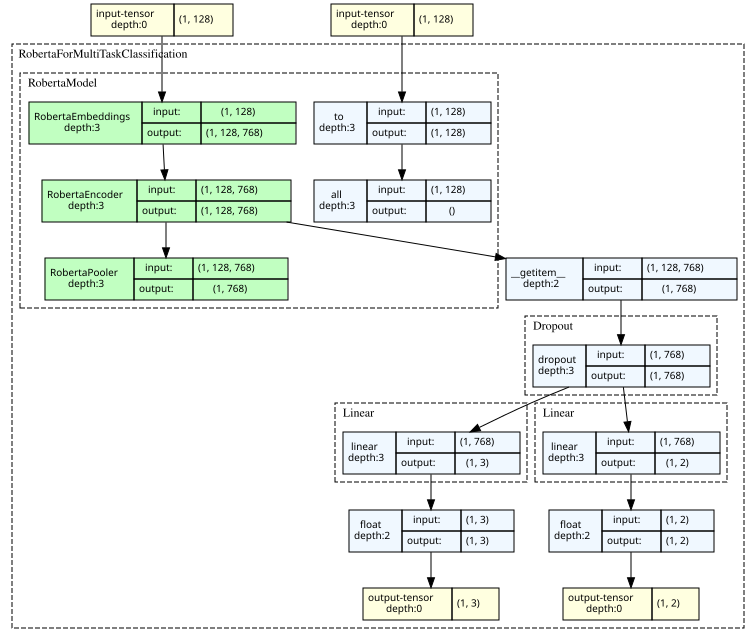

In [ ]:
class _TorchviewWrapper(nn.Module):
    def __init__(self, multitask_model):
        super().__init__()
        self.roberta_model = multitask_model

    def forward(self, input_ids, attention_mask):
        out = self.roberta_model(input_ids=input_ids, attention_mask=attention_mask)
        return out['polarity_logits'], out['subjectivity_logits']

# Setup model
device = next(model.parameters()).device
wrapped = _TorchviewWrapper(model).to(device).eval()

# Use a standard shape (Batch Size 1, Sequence Length 128)
dummy_input_ids = torch.zeros((1, 128), dtype=torch.long).to(device)
dummy_mask = torch.ones((1, 128), dtype=torch.long).to(device)

# Generate Graph
graph = draw_graph(
    wrapped,
    input_data=(dummy_input_ids, dummy_mask),
    graph_name='RoBERTa_Multitask_Architecture',
    expand_nested=True,
    depth=3,
    device=device,
    hide_inner_tensors=True,
    hide_module_functions=False,
    save_graph=True,
    filename="roberta_architecture_final"
)

# Render
graph.visual_graph

## Evaluation helpers

In [49]:
def predict_multitask(model, tokenizer, texts, batch_size=32, max_length=MAX_LENGTH):
    model.eval()
    device = next(model.parameters()).device

    all_polarity_logits = []
    all_subjectivity_logits = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt',
            ).to(device)
            outputs = model(**enc)
            all_polarity_logits.append(outputs['polarity_logits'].cpu().numpy())
            all_subjectivity_logits.append(outputs['subjectivity_logits'].cpu().numpy())

    polarity_logits = np.vstack(all_polarity_logits)
    subjectivity_logits = np.vstack(all_subjectivity_logits)
    polarity_pred = polarity_logits.argmax(axis=-1)
    subjectivity_pred = subjectivity_logits.argmax(axis=-1)
    return polarity_pred, subjectivity_pred, polarity_logits, subjectivity_logits


def evaluate_task(y_true, y_pred, id2label, prefix, eval_data_name, task_name, output_dir):
    labels_order = list(id2label.keys())
    target_names = [id2label[i] for i in labels_order]

    print('\n' + '=' * 60)
    print(f'Evaluation on {eval_data_name}')
    print('=' * 60)
    print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
    print(f'\n{task_name} classification performance:')
    print(
        classification_report(
            y_true,
            y_pred,
            labels=labels_order,
            target_names=target_names,
            digits=4,
            zero_division=0,
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels_order)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax,
        cbar_kws={'label': 'Count'},
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(f'Muti-Task RoBERTa {task_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    figure_path = output_dir / f"{prefix.lower().replace(' ', '_')}_confusion_matrix.png"
    fig.savefig(figure_path, dpi=150, bbox_inches='tight')
    print('\nSaved figure:', figure_path)

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_order, average=None, zero_division=0
    )
    metrics_rows = []
    for i, name in enumerate(target_names):
        metrics_rows.append(
            {'class': name, 'precision': prec[i], 'recall': rec[i], 'f1': f1[i], 'support': int(sup[i])}
        )

    summary_rows = []
    for avg in ('macro', 'weighted'):
        p_a, r_a, f_a, _ = precision_recall_fscore_support(y_true, y_pred, average=avg, zero_division=0)
        summary_rows.append({'average_type': avg, 'precision': p_a, 'recall': r_a, 'f1': f_a, 'support': int(len(y_true))})

    metrics_df = pd.DataFrame(metrics_rows)
    summary_df = pd.DataFrame(summary_rows)
    metrics_csv = output_dir / f"{prefix.lower().replace(' ', '_')}_metrics.csv"
    with pd.ExcelWriter(metrics_csv.with_suffix('.xlsx')) as writer:
        metrics_df.to_excel(writer, sheet_name='per_class', index=False)
        summary_df.to_excel(writer, sheet_name='summary', index=False)
    metrics_df.to_csv(metrics_csv, index=False)
    print('Saved metrics:', metrics_csv)

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'metrics_df': metrics_df,
        'summary_df': summary_df,
        'confusion_matrix': cm,
    }


def evaluate_multitask_dataframe(model, tokenizer, frame, output_dir, prefix, eval_data_name):
    eval_dir = output_dir / prefix
    eval_dir.mkdir(parents=True, exist_ok=True)

    texts = frame[TEXT_COL].astype(str).tolist()
    polarity_true = frame['polarity_labels'].values
    subjectivity_true = frame['subjectivity_labels'].values

    polarity_pred, subjectivity_pred, _, _ = predict_multitask(model, tokenizer, texts)

    polarity_results = evaluate_task(
        polarity_true,
        polarity_pred,
        POLARITY_ID2LABEL,
        prefix,
        eval_data_name,
        'Polarity',
        eval_dir,
    )
    subjectivity_results = evaluate_task(
        subjectivity_true,
        subjectivity_pred,
        SUBJECTIVITY_ID2LABEL,
        prefix,
        eval_data_name,
        'Subjectivity',
        eval_dir,
    )

    return {
        'polarity': polarity_results,
        'subjectivity': subjectivity_results,
    }

## Evaluate on validation split


Evaluation on Validation Data
Accuracy: 0.9965

Polarity classification performance:
              precision    recall  f1-score   support

    Negative     0.9928    0.9954    0.9941      1524
     Neutral     0.9923    0.9969    0.9946      1943
    Positive     0.9998    0.9966    0.9982      4168

    accuracy                         0.9965      7635
   macro avg     0.9950    0.9963    0.9956      7635
weighted avg     0.9965    0.9965    0.9965      7635



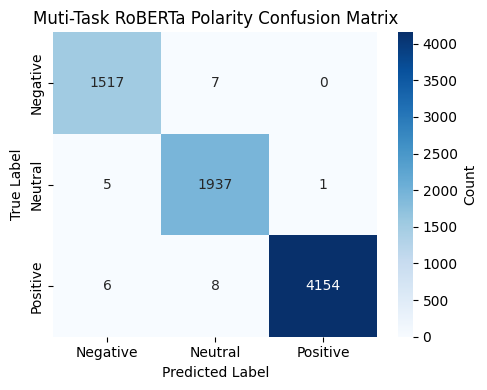


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/validation/validation_confusion_matrix.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/validation/validation_metrics.csv

Evaluation on Validation Data
Accuracy: 0.9971

Subjectivity classification performance:
              precision    recall  f1-score   support

   Objective     0.9923    0.9964    0.9944      1943
  Subjective     0.9988    0.9974    0.9981      5692

    accuracy                         0.9971      7635
   macro avg     0.9955    0.9969    0.9962      7635
weighted avg     0.9971    0.9971    0.9971      7635



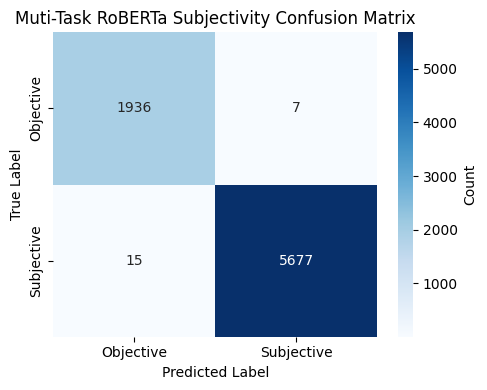


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/validation/validation_confusion_matrix.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/validation/validation_metrics.csv


In [50]:
val_results = evaluate_multitask_dataframe(model, tokenizer, val_df, OUTPUT_DIR, 'validation', 'Validation Data')

## Evaluate on evaluation data

Evaluation csv rows with both labels: 1000

Evaluation on corpus_evaluation.csv
Accuracy: 0.8590

Polarity classification performance:
              precision    recall  f1-score   support

    Negative     0.7909    0.8920    0.8385       352
     Neutral     0.8989    0.8164    0.8557       207
    Positive     0.9060    0.8526    0.8785       441

    accuracy                         0.8590      1000
   macro avg     0.8653    0.8537    0.8576      1000
weighted avg     0.8640    0.8590    0.8597      1000



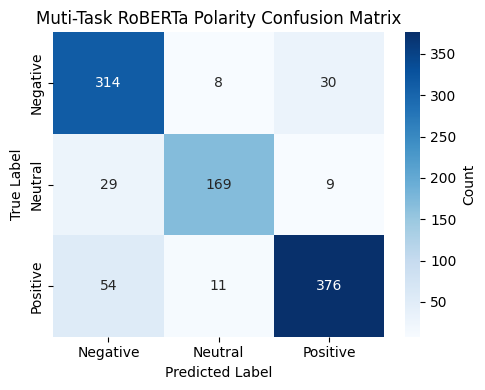


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/evaluation/evaluation_confusion_matrix.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/evaluation/evaluation_metrics.csv

Evaluation on corpus_evaluation.csv
Accuracy: 0.9460

Subjectivity classification performance:
              precision    recall  f1-score   support

   Objective     0.8989    0.8284    0.8622       204
  Subjective     0.9569    0.9761    0.9664       796

    accuracy                         0.9460      1000
   macro avg     0.9279    0.9023    0.9143      1000
weighted avg     0.9451    0.9460    0.9452      1000



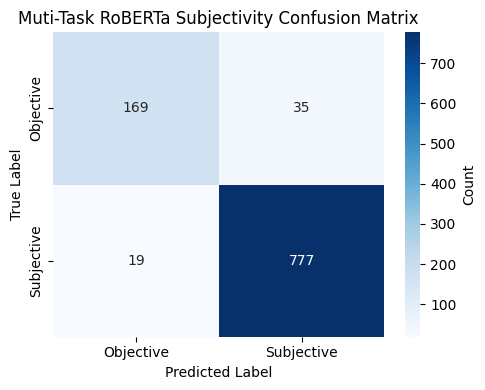


Saved figure: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/evaluation/evaluation_confusion_matrix.png
Saved metrics: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/evaluation/evaluation_metrics.csv
Saved evaluation predictions: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/roberta_multitask_eval_predictions.csv


In [ ]:
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)
transformers_logging.set_verbosity_error()

eval_raw = pd.read_csv(EVAL_CSV, encoding='utf-8')
keep_cols = [c for c in ['doc_id', 'object_id', TEXT_COL, 'label_sentiment', 'label_subjectivity'] if c in eval_raw.columns]
eval_df = eval_raw[keep_cols].dropna(subset=[TEXT_COL, 'label_sentiment', 'label_subjectivity']).copy()

eval_df[TEXT_COL] = eval_df[TEXT_COL].astype(str).str.strip()
eval_df['label_sentiment'] = eval_df['label_sentiment'].astype(str).str.strip().replace(polarity_cap_map)
eval_df['label_subjectivity'] = eval_df['label_subjectivity'].astype(str).str.strip().replace(subjectivity_cap_map)
eval_df['polarity_labels'] = eval_df['label_sentiment'].map(POLARITY_LABEL2ID)
eval_df['subjectivity_labels'] = eval_df['label_subjectivity'].map(SUBJECTIVITY_LABEL2ID)
eval_df = eval_df.dropna(subset=['polarity_labels', 'subjectivity_labels']).copy()
eval_df['polarity_labels'] = eval_df['polarity_labels'].astype(int)
eval_df['subjectivity_labels'] = eval_df['subjectivity_labels'].astype(int)

print('Evaluation csv rows with both labels:', len(eval_df))
eval_results = evaluate_multitask_dataframe(model, tokenizer, eval_df, OUTPUT_DIR,'evaluation' , 'corpus_evaluation.csv')

# Export evaluation predictions
texts = eval_df[TEXT_COL].astype(str).tolist()
pol_pred, sub_pred, _, _ = predict_multitask(model, tokenizer, texts)

pred_export = eval_df[[c for c in ['doc_id', 'object_id', 'text'] if c in eval_df.columns]].copy()
pred_export['pred_polarity'] = pd.Series(pol_pred).map(POLARITY_ID2LABEL).values
pred_export['pred_subjectivity'] = pd.Series(sub_pred).map(SUBJECTIVITY_ID2LABEL).values

pred_export_csv = OUTPUT_DIR / 'roberta_multitask_eval_predictions.csv'
pred_export.to_csv(pred_export_csv, index=False)
print('Saved evaluation predictions:', pred_export_csv)

## Print performance summary

In [ ]:
def _get_class_row(metrics_df, class_name):
    return metrics_df[metrics_df['class'] == class_name].iloc[0]


def build_summary(task_results, task_name):
    metrics_df = task_results['metrics_df']
    summary_df = task_results['summary_df']

    macro_row = summary_df[summary_df['average_type'] == 'macro'].iloc[0]
    weighted_row = summary_df[summary_df['average_type'] == 'weighted'].iloc[0]

    row = {
        'task': task_name,
        'accuracy': task_results['accuracy'],
        'macro_f1': macro_row['f1'],
        'weighted_f1': weighted_row['f1'],
    }

    for cls in metrics_df['class'].tolist():
        r = _get_class_row(metrics_df, cls)
        prefix = cls.lower()
        row[f'{prefix}_f1'] = r['f1']
        row[f'{prefix}_precision'] = r['precision']
        row[f'{prefix}_recall'] = r['recall']

    return row

summary_rows = []

# Create validation summaries
summary_rows.append(build_summary(val_results['polarity'], 'validation_polarity'))
summary_rows.append(build_summary(val_results['subjectivity'], 'validation_subjectivity'))
summary_rows.append(build_summary(eval_results['polarity'], 'evaluation_polarity'))
summary_rows.append(build_summary(eval_results['subjectivity'], 'evaluation_subjectivity'))

summary_df = pd.DataFrame(summary_rows)

polarity_df = summary_df[summary_df["task"].str.contains("polarity")].reset_index(drop=True)
polarity_cols = [col for col in polarity_df.columns if any(x in col for x in ['task', 'accuracy', 'macro', 'weighted', 'pos', 'neg', 'neu'])]
polarity_df = polarity_df[polarity_cols].dropna(axis=1, how='all')
subjectivity_df = summary_df[summary_df["task"].str.contains("subjectivity")].reset_index(drop=True)
subjectivity_cols = [col for col in subjectivity_df.columns if any(x in col for x in ['task', 'accuracy', 'macro', 'weighted', 'subj', 'obj'])]
subjectivity_df = subjectivity_df[subjectivity_cols].dropna(axis=1, how='all')

polarity_csv = OUTPUT_DIR / "roberta_multitask_polarity_performance.csv"
subjectivity_csv = OUTPUT_DIR / "roberta_multitask_subjectivity_performance.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
polarity_df.to_csv(polarity_csv, index=False)
subjectivity_df.to_csv(subjectivity_csv, index=False)

print("Saved polarity performance to:", polarity_csv)
print("Saved subjectivity performance to:", subjectivity_csv)
print('\nMulti-Task RoBERTa Polarity Performance')
display(polarity_df)
print('\nMulti-Task RoBERTa Subjectivity Performance')
display(subjectivity_df)

Saved polarity performance to: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/roberta_multitask_polarity_performance.csv
Saved subjectivity performance to: /content/drive/MyDrive/NTU/Y3S2/SC4021 Information Retrieval/SC4021 Project/outputs/roberta_multitask_combined/roberta_multitask_subjectivity_performance.csv

Multi-Task RoBERTa Polarity Performance


,task,accuracy,macro_f1,weighted_f1,negative_f1,negative_precision,negative_recall,neutral_f1,neutral_precision,neutral_recall,positive_f1,positive_precision,positive_recall
0,validation_polarity,0.996464,0.995636,0.996467,0.994102,0.992801,0.995407,0.994608,0.992316,0.996912,0.998198,0.999759,0.996641
1,evaluation_polarity,0.859000,0.857551,0.859685,0.838451,0.790932,0.892045,0.855696,0.898936,0.816425,0.878505,0.906024,0.852608



Multi-Task RoBERTa Subjectivity Performance


,task,accuracy,macro_f1,weighted_f1,objective_f1,objective_precision,objective_recall,subjective_f1,subjective_precision,subjective_recall
0,validation_subjectivity,0.997119,0.996208,0.997120,0.994350,0.992312,0.996397,0.998066,0.998768,0.997365
1,evaluation_subjectivity,0.946000,0.914331,0.945167,0.862245,0.898936,0.828431,0.966418,0.956897,0.976131
